# Notebook 03A - Detection Optimization

## Objective

Improve MediaPipe hand detection by testing different image enhancement techniques.

Methods to compare:

1. Original Image
2. Brightness Enhancement
3. Histogram Equalization
4. CLAHE
5. Gamma Correction

The method with the highest landmark detection rate will be used for generating the final dataset.

In [2]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [3]:
#MediaPipe initialization
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.30,
    min_tracking_confidence=0.30
)

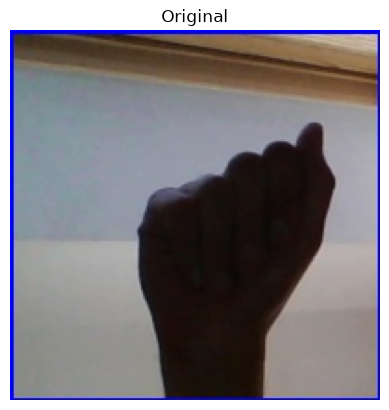

In [4]:
failed_image = Path(r"..\dataset\raw\asl_alphabet_train\A\A100.jpg")

image = cv2.imread(str(failed_image))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original")
plt.show()

In [6]:
def brighten(image):
    return cv2.convertScaleAbs(image, alpha=1.3, beta=30)

In [7]:
def equalize(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    gray = cv2.equalizeHist(gray)

    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

In [8]:
def clahe(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    gray = clahe.apply(gray)

    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

In [9]:
def gamma(image, gamma=1.5):

    inv = 1 / gamma

    table = np.array([
        ((i / 255.0) ** inv) * 255
        for i in range(256)
    ]).astype("uint8")

    return cv2.LUT(image, table)

In [10]:
methods = {
    "Original": image_rgb,
    "Bright": brighten(image_rgb),
    "Equalized": equalize(image_rgb),
    "CLAHE": clahe(image_rgb),
    "Gamma": gamma(image_rgb)
}

In [11]:
for name, img in methods.items():

    results = hands.process(img)

    print(
        name,
        "Detected" if results.multi_hand_landmarks else "Failed"
    )

Original Failed
Bright Detected
Equalized Failed
CLAHE Failed
Gamma Detected


d:\Code FIles\VS code files\Project\sign-language-translator\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


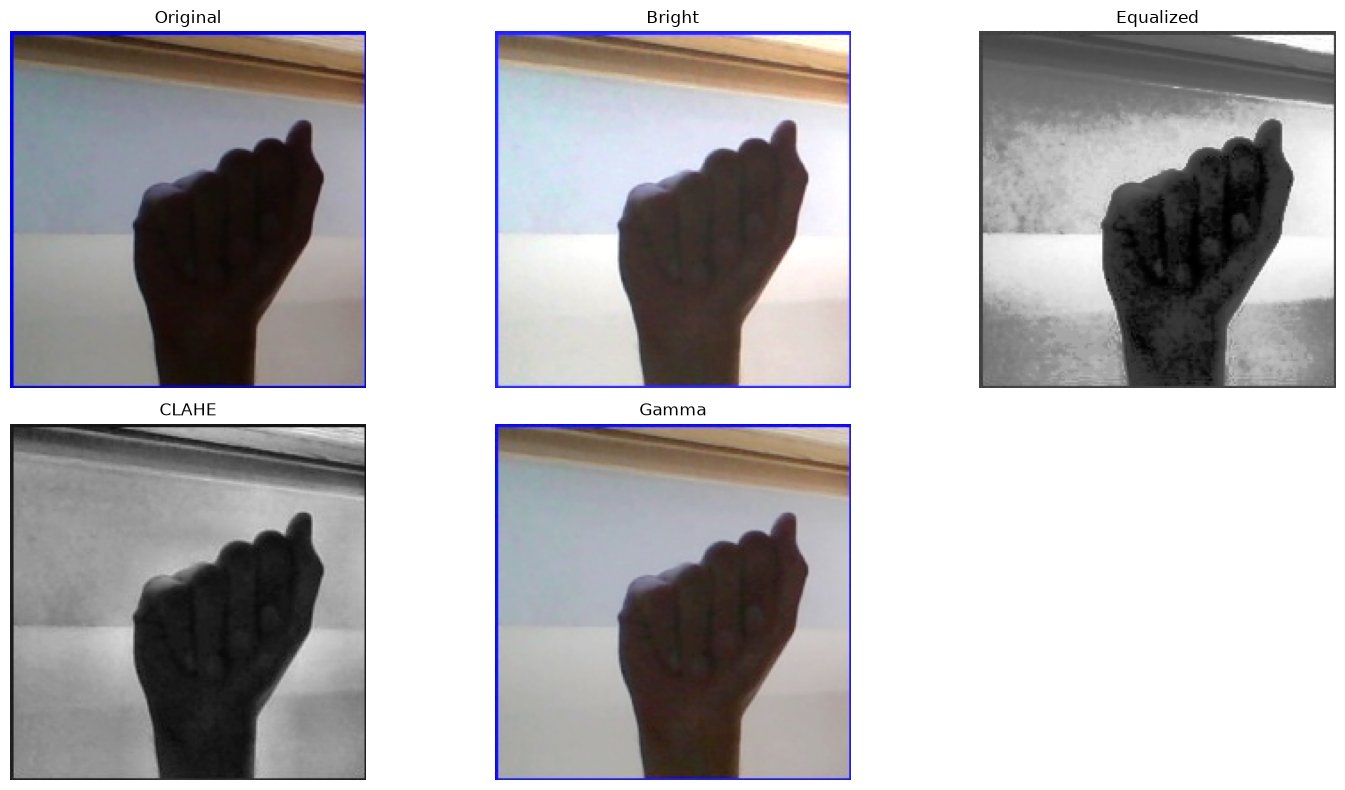

In [12]:
plt.figure(figsize=(15,8))

for i, (name, img) in enumerate(methods.items()):

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(name)

    plt.axis("off")

plt.tight_layout()

plt.show()